# Combined Cycle Power Plant Output Prediction using ANN (Regression)

This notebook builds an Artificial Neural Network using **TensorFlow / Keras** to predict the **net hourly electrical energy output (PE)** of a combined cycle power plant.

**Dataset**: UCI Combined Cycle Power Plant (CCPP) - 9,568 hourly observations, downloaded programmatically from the UCI ML repository.

**Features**:
- `AT` - Ambient Temperature (degC)
- `V`  - Exhaust Vacuum (cm Hg)
- `AP` - Ambient Pressure (mbar)
- `RH` - Relative Humidity (%)

**Target**:
- `PE` - Net hourly electrical energy output (MW)

Pipeline:
- `Dense` layers
- `BatchNormalization` (to stabilise / speed up training)
- `Dropout` (to reduce overfitting)
- `EarlyStopping` callback

## 1. Import Libraries

In [1]:
import io
import ssl
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

I0000 00:00:1787210379.577048   48698 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787210379.632363   48698 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787210381.201779   48698 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 2. Download & Load the Dataset

The dataset is downloaded **programmatically** from the UCI ML repository and read directly from the Excel file inside the ZIP - no manual download required.

In [2]:
# url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00294/CCPP.zip"

# # SSL workaround for environments with strict certificate checks
# ctx = ssl.create_default_context()
# ctx.check_hostname = False
# ctx.verify_mode = ssl.CERT_NONE

# req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
# with urllib.request.urlopen(req, context=ctx, timeout=60) as resp:
#     zip_bytes = resp.read()

# print(f"Downloaded {len(zip_bytes):,} bytes")

# with zipfile.ZipFile(io.BytesIO(zip_bytes)) as z:
#     with z.open("CCPP/Folds5x2_pp.xlsx") as f:
#         df = pd.read_excel(f)

# df.head()

In [3]:
df = pd.read_csv("CCPP.csv")
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [4]:
df.shape

(9568, 5)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [6]:
df.describe()

,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


## 3. Data Cleaning

In [7]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("After dropping duplicates:", df.shape)

Duplicate rows: 41
After dropping duplicates: (9527, 5)


In [8]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

## 4. Exploratory Data Analysis

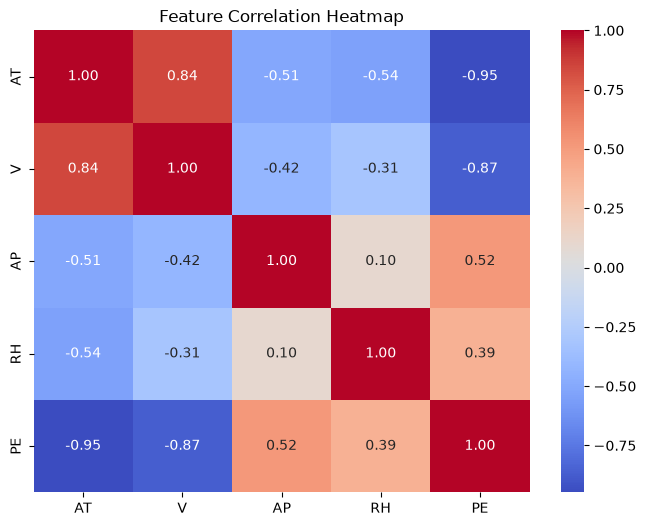

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

In [10]:
target = "PE"     
X = df.drop(columns=[target])

corr_matrix = X.corr().abs()

columns_to_drop = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > 0.8:
            col1 = corr_matrix.columns[j]
            col2 = corr_matrix.columns[i]
            corr = corr_matrix.iloc[i, j]

            print(f"{col1} ↔ {col2} = {corr:.3f}")

            columns_to_drop.append(col2)

print("\nColumns to drop:", columns_to_drop)

AT ↔ V = 0.844

Columns to drop: ['V']


In [11]:
df.drop(columns=columns_to_drop, inplace=True)

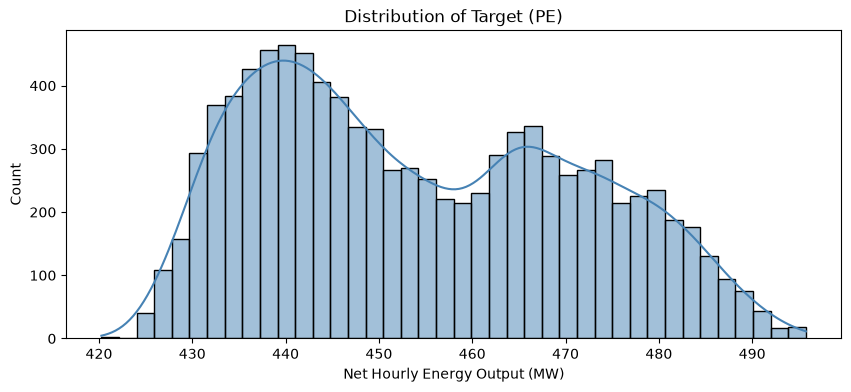

In [12]:
plt.figure(figsize=(10, 4))
sns.histplot(df['PE'], kde=True, bins=40, color='steelblue')
plt.title('Distribution of Target (PE)')
plt.xlabel('Net Hourly Energy Output (MW)')
plt.show()

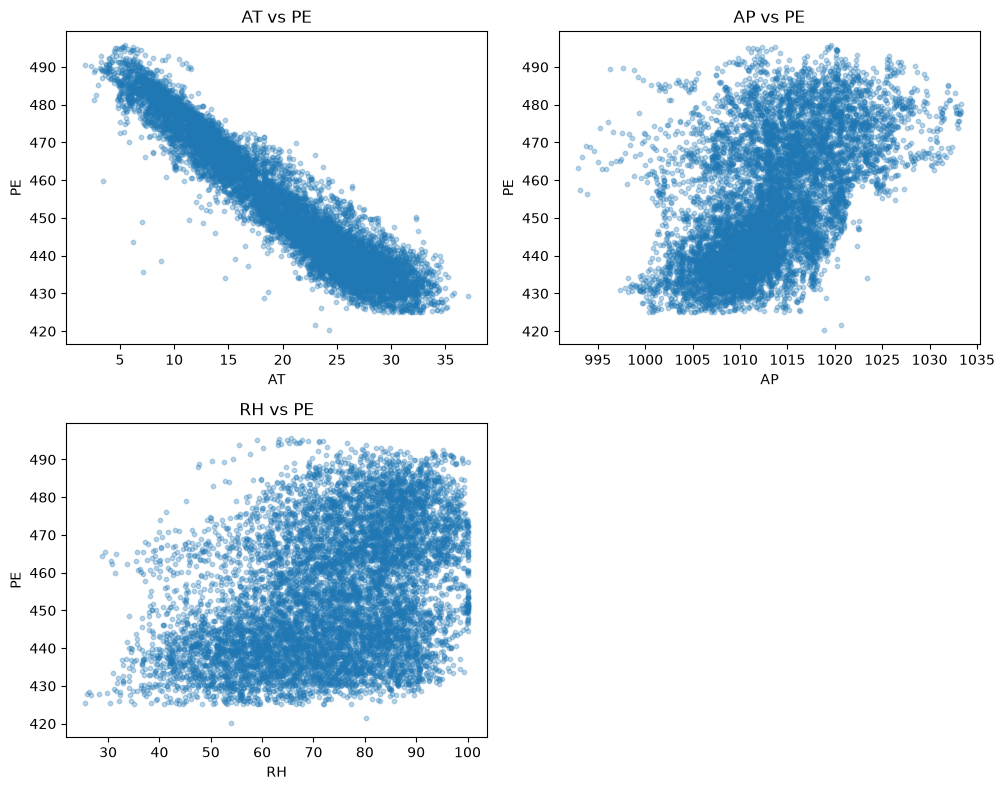

In [13]:
import matplotlib.pyplot as plt

cols = ['AT', 'AP', 'RH']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    ax.scatter(df[col], df['PE'], alpha=0.3, s=10)
    ax.set_xlabel(col)
    ax.set_ylabel('PE')
    ax.set_title(f'{col} vs PE')

# Remove the unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

## 5. Train / Test Split

In [14]:
X = df.drop(columns=['PE'])
y = df['PE']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=1
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("y_train:", y_train.shape, " y_test:", y_test.shape)

X_train: (6668, 3)  X_test: (2859, 3)
y_train: (6668,)  y_test: (2859,)


## 6. Feature Scaling

Only the **features (X)** are scaled with `MinMaxScaler`. The target `PE` is kept in its original scale (MW) so all metrics are directly interpretable.

In [15]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

n_features = X_train_scaled.shape[1]
print("n_features:", n_features)

n_features: 3


## 7. Build the ANN

In [16]:
model = Sequential()

# Input layer
model.add(Input(shape=(n_features,))) # To pass as a tuple, without comma(,), it would be an integer

model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.1))

# Output layer
model.add(Dense(1, activation='linear'))

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

E0000 00:00:1787210391.902076   48698 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1787210391.902525   48899 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1787210391.920900   48698 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,561 (10.00 KB)

 Non-trainable params: 192 (768.00 B)

## 8. Train the Model

`EarlyStopping` halts training once the validation loss stops improving and restores the best weights.

In [17]:
early_stop = EarlyStopping(
    monitor="val_loss",
    min_delta=0.01,
    patience=25,
    verbose=1,
    mode="min",
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 205700.8750 - mae: 453.3430 - val_loss: 203929.5156 - val_mae: 451.3024
Epoch 2/200
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 201617.1875 - mae: 448.9390 - val_loss: 197768.3906 - val_mae: 444.5412
Epoch 3/200
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 193746.9375 - mae: 440.1087 - val_loss: 186809.8906 - val_mae: 432.1409
Epoch 4/200
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 182405.9531 - mae: 427.0099 - val_loss: 172653.5938 - val_mae: 415.4826
Epoch 5/200
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 168219.9062 - mae: 410.0340 - val_loss: 159614.3281 - val_mae: 399.4853
Epoch 6/200
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 152026.3906 - mae: 389.7740 - val_loss: 144181.9219 - val_mae: 379.6708
Epoch 7/200
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 134275.4844 - mae: 366.2426 - val_loss: 128968.0234 - val_mae: 359.0848
Epoch 8/200
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 116233.7

## 9. Training History

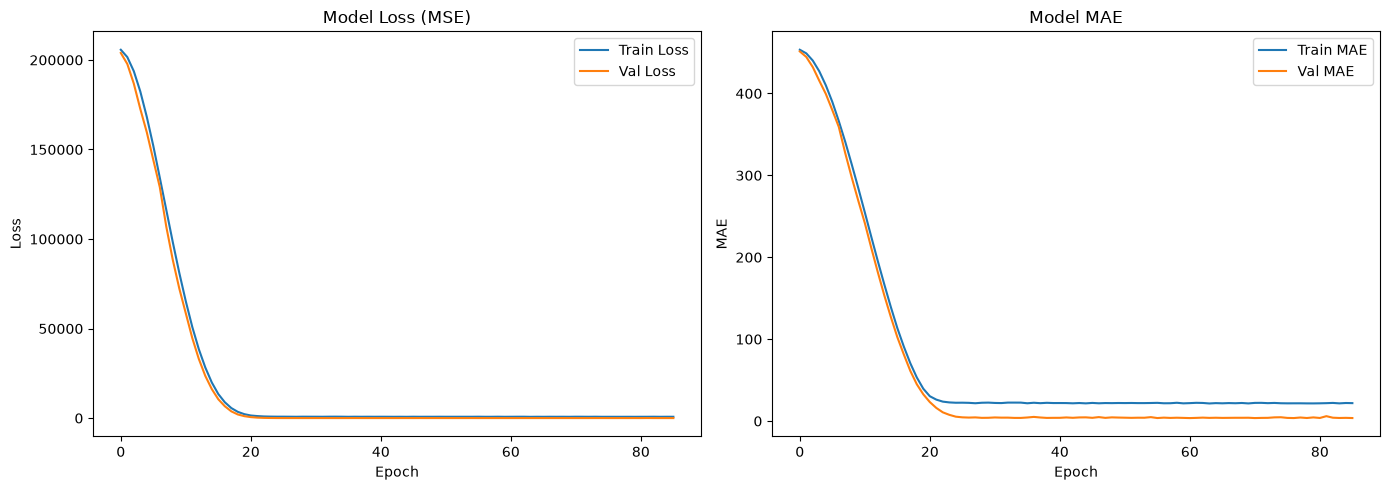

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Model Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# MAE
axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('Model MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Evaluate on Test Set

In [19]:
y_pred = model.predict(X_test_scaled).flatten()

y_test_arr = y_test.values
for actual, pred in zip(y_test_arr[10:20], y_pred[10:20]):
    print(f"Actual: {actual:>8.2f}   Predicted: {pred:>8.2f}")

90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Actual:   440.87   Predicted:   443.13
Actual:   448.51   Predicted:   450.93
Actual:   456.86   Predicted:   459.51
Actual:   449.96   Predicted:   448.36
Actual:   432.10   Predicted:   435.84
Actual:   430.26   Predicted:   435.89
Actual:   450.46   Predicted:   446.13
Actual:   476.83   Predicted:   478.93
Actual:   456.62   Predicted:   455.19
Actual:   471.31   Predicted:   464.46


In [20]:
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R\u00b2 Score : {r2:.4f}")
print(f"MAE       : {mae:.4f}")
print(f"RMSE      : {rmse:.4f}")

R² Score : 0.9286
MAE       : 3.6507
RMSE      : 4.5826


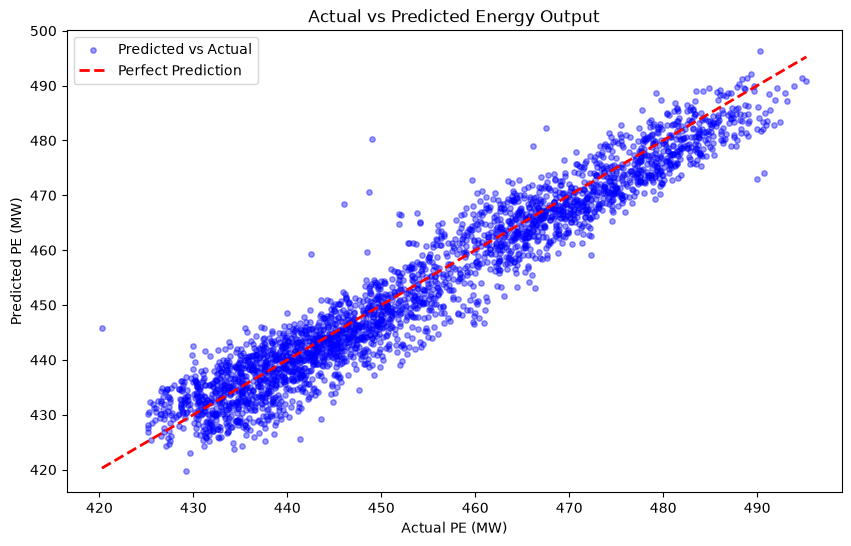

In [21]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.4, s=15, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual PE (MW)')
plt.ylabel('Predicted PE (MW)')
plt.title('Actual vs Predicted Energy Output')
plt.legend()
plt.show()

## 11. Inference on New Data

Helper that takes raw sensor values, applies the same scaling pipeline, then predicts using the trained ANN.

In [22]:
def predict_pe(at,ap, rh):
    input_df = pd.DataFrame({
        'AT': [at],
        'AP': [ap],
        'RH': [rh]
    })
    input_scaled = scaler.transform(input_df)
    prediction = model.predict(input_scaled, verbose=0).flatten()[0]
    return f"Estimated Net Hourly Energy Output: {prediction:,.2f} MW"

# Examples (real rows from the dataset, actual PE shown in comments)
print(predict_pe(at=14.96, ap=1024.07, rh=73.17))  # actual ~ 463.26
print(predict_pe(at=25.18, ap=1020.04, rh=59.08))  # actual ~ 444.37
print(predict_pe(at=5.11, ap=1012.16, rh=92.14))  # actual ~ 488.56

Estimated Net Hourly Energy Output: 463.96 MW
Estimated Net Hourly Energy Output: 443.49 MW
Estimated Net Hourly Energy Output: 485.31 MW


In [23]:
# model.save('ccpp_ann_model.keras')
# print('Model saved to ccpp_ann_model.keras')